<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/ResNet(imagenet).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/Untitled folder/archive (4).zip"  # apna filename check kar lena
extract_path = "/content/tiny-imagenet"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✅")

Extraction Done ✅


In [10]:
# =====================
# 1. IMPORTS
# =====================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt


In [4]:
# =====================
# 2. DATA
# =====================
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

In [5]:
train_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/train",transform=transform)
val_data = datasets.ImageFolder("/content/tiny-imagenet/tiny-imagenet-200/val",transform=transform)

In [6]:
train_loader= DataLoader(train_data,batch_size=32,shuffle=True)
val_loader = DataLoader(val_data,batch_size=32)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# =====================
# 3. MODEL
# =====================
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 200)
model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


In [8]:
# =====================
# 4. TRAIN
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses = []

for epoch in range(5):
    total_loss = 0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    losses.append(total_loss)
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 11036.3526
Epoch 2, Loss: 10040.9439
Epoch 3, Loss: 9923.9592
Epoch 4, Loss: 9810.6827
Epoch 5, Loss: 9775.5348


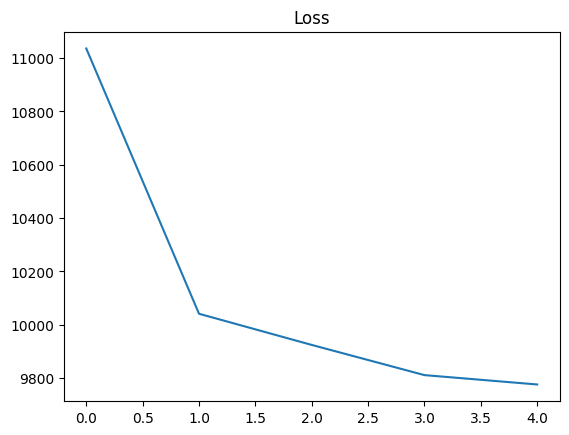

In [11]:
# =====================
# 5. GRAPH
# =====================
plt.plot(losses)
plt.title("Loss")
plt.show()


In [12]:
# =====================
# 5. ACCURACY
# =====================
model.eval()
correct, total = 0,0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs,1)
        total += labels.size(0)
        correct += (pred==labels).sum().item()

print("Accuracy:", 100*correct/total)

Accuracy: 0.36
